In [1]:
# ── Setup ─────────────────────────────────────────────────────────────

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
)

ROOT_DIR     = Path(r"C:\Users\sharg\Desktop\github\FinRiskGuard")
MODELS_DIR   = ROOT_DIR / "outputs" / "models"  / "credit"
FEATURES_DIR = ROOT_DIR / "data"    / "features" / "credit"
FIG_BASE     = ROOT_DIR / "outputs" / "figures"  / "credit"

for sub in ["comparison", "model", "shap"]:
    (FIG_BASE / sub).mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"]    = (12, 6)
plt.rcParams["font.size"]         = 12
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

val   = pd.read_parquet(FEATURES_DIR / "val_credit_features.parquet")
X_val = val.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y_val = val["TARGET"]

with open(MODELS_DIR / "credit_model_metadata.json") as f:
    metadata = json.load(f)

leaderboard = metadata["leaderboard"]
model_name  = metadata["model_name"]
threshold   = metadata["threshold"]

print("=" * 50)
print(f"Best model   : {model_name}")
print(f"AUC-ROC      : {metadata['auc_roc']:.4f}")
print(f"AUC-PR       : {metadata['auc_pr']:.4f}")
print(f"F1           : {metadata['f1']:.4f}")
print(f"Precision    : {metadata['precision']:.4f}")
print(f"Recall       : {metadata['recall']:.4f}")
print(f"Threshold    : {threshold:.3f}")
print(f"Val shape    : {X_val.shape}")
print(f"Default rate : {y_val.mean()*100:.2f}%")
print(f"Default count: {y_val.sum():,}")

Best model   : stacking
AUC-ROC      : 0.7849
AUC-PR       : 0.2854
F1           : 0.2896
Precision    : 0.1819
Recall       : 0.7098
Threshold    : 0.500
Val shape    : (61503, 105)
Default rate : 8.07%
Default count: 4,965


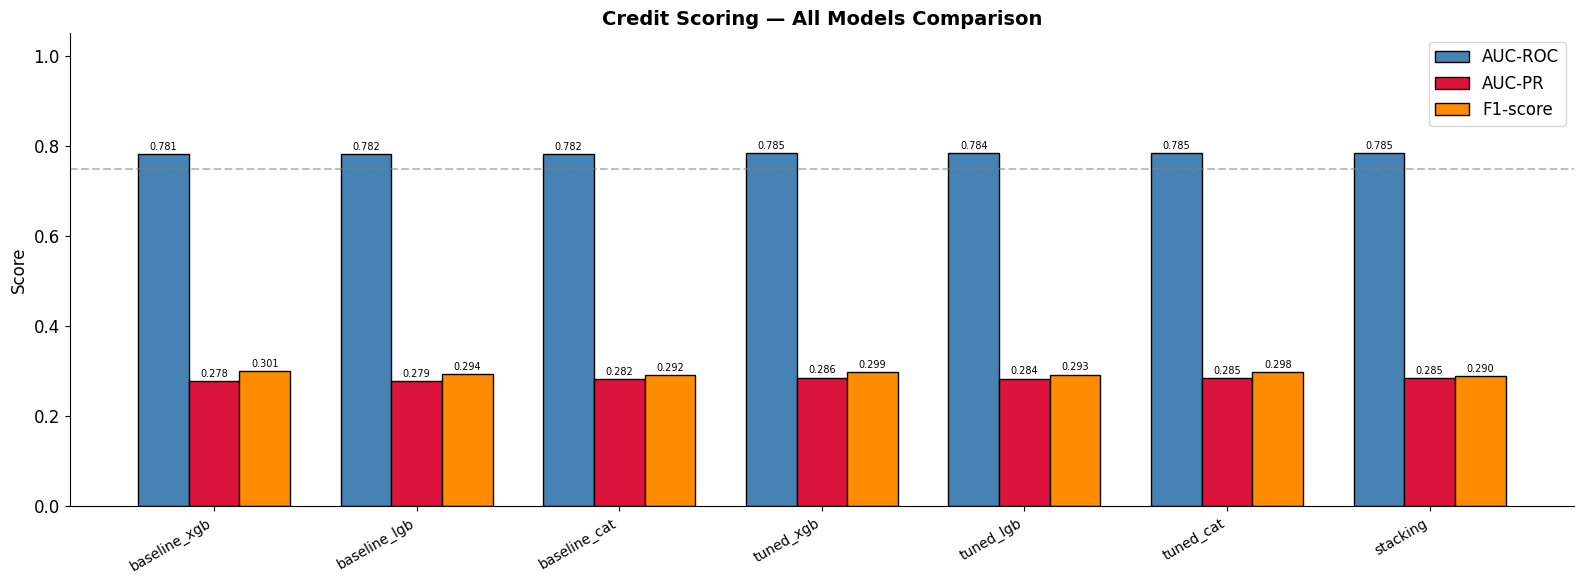

Leaderboard (by AUC-ROC):
  #1 stacking             AUC-ROC=0.7849 | AUC-PR=0.2854 | F1=0.2896 ← BEST
  #2 tuned_cat            AUC-ROC=0.7848 | AUC-PR=0.2852 | F1=0.2984
  #3 tuned_xgb            AUC-ROC=0.7846 | AUC-PR=0.2857 | F1=0.2987
  #4 tuned_lgb            AUC-ROC=0.7840 | AUC-PR=0.2837 | F1=0.2926
  #5 baseline_cat         AUC-ROC=0.7822 | AUC-PR=0.2820 | F1=0.2916
  #6 baseline_lgb         AUC-ROC=0.7816 | AUC-PR=0.2786 | F1=0.2944
  #7 baseline_xgb         AUC-ROC=0.7814 | AUC-PR=0.2783 | F1=0.3010


In [2]:
# ──— Model Comparison Leaderboard ─────────────────────────

names = list(leaderboard.keys())
aucs  = [v["auc_roc"] for v in leaderboard.values()]
auprs = [v["auc_pr"]  for v in leaderboard.values()]
f1s   = [v["f1"]      for v in leaderboard.values()]

x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - width, aucs,  width, label="AUC-ROC",  color="steelblue",  edgecolor="black")
b2 = ax.bar(x,         auprs, width, label="AUC-PR",   color="crimson",    edgecolor="black")
b3 = ax.bar(x + width, f1s,   width, label="F1-score", color="darkorange", edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Credit Scoring — All Models Comparison", fontsize=14, fontweight="bold")
ax.legend()
ax.axhline(y=0.75, color="gray", linestyle="--", alpha=0.5, label="0.75 reference")

for bar in [*b1, *b2, *b3]:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(FIG_BASE / "comparison" / "01_model_leaderboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("Leaderboard (by AUC-ROC):")
for i, (name, m) in enumerate(
    sorted(leaderboard.items(), key=lambda x: x[1]["auc_roc"], reverse=True), 1
):
    marker = " ← BEST" if name == model_name else ""
    print(f"  #{i} {name:<20} AUC-ROC={m['auc_roc']:.4f} | AUC-PR={m['auc_pr']:.4f} | F1={m['f1']:.4f}{marker}")

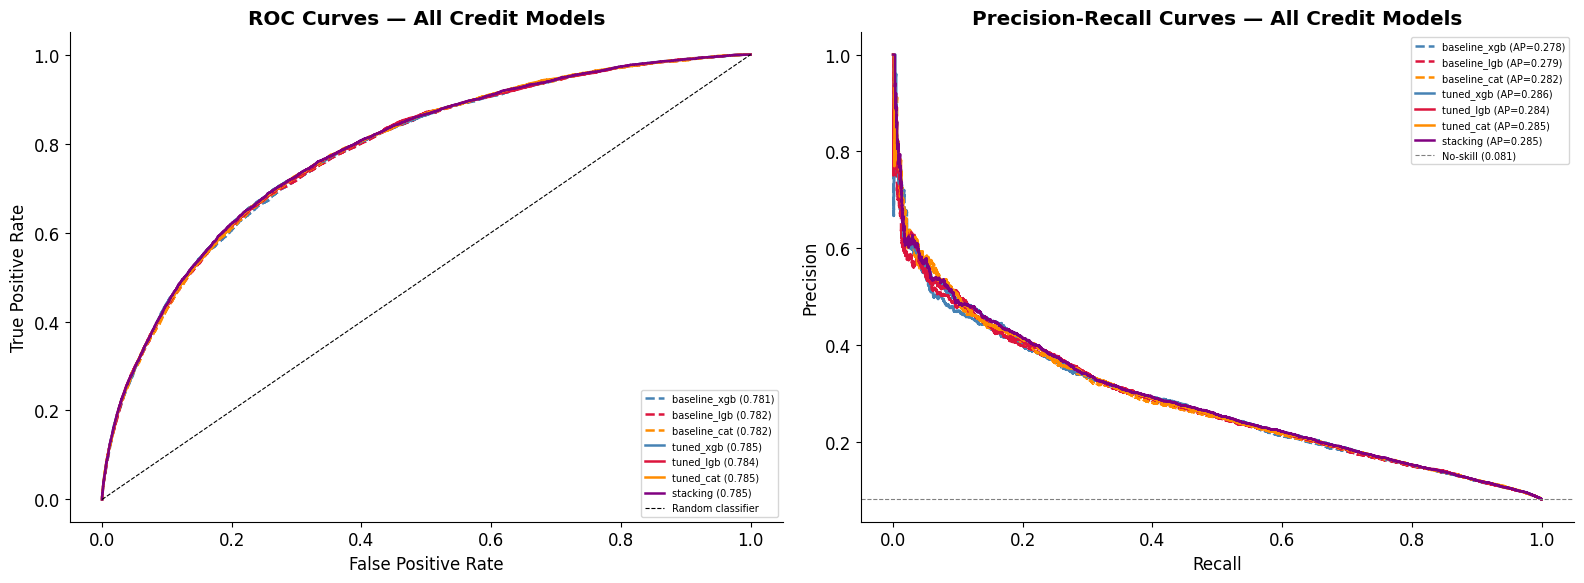

Saved: model/02_roc_pr_curves.png


In [3]:
# ─ROC & Precision-Recall Curves ────────────────────────

COLORS = {
    "baseline_xgb": ("steelblue",  "--"),
    "baseline_lgb": ("crimson",    "--"),
    "baseline_cat": ("darkorange", "--"),
    "tuned_xgb"   : ("steelblue",  "-"),
    "tuned_lgb"   : ("crimson",    "-"),
    "tuned_cat"   : ("darkorange", "-"),
    "stacking"    : ("purple",     "-"),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, metrics in leaderboard.items():
    color, ls = COLORS.get(name, ("gray", "-"))
    try:
        if name == "stacking":
            xgb_p = joblib.load(MODELS_DIR / "tuned_xgb.pkl").predict_proba(X_val)[:, 1]
            lgb_p = joblib.load(MODELS_DIR / "tuned_lgb.pkl").predict_proba(X_val)[:, 1]
            cat_p = joblib.load(MODELS_DIR / "tuned_cat.pkl").predict_proba(X_val)[:, 1]
            meta  = joblib.load(MODELS_DIR / "stacking_meta.pkl")
            prob  = meta.predict_proba(np.column_stack([xgb_p, lgb_p, cat_p]))[:, 1]
        else:
            parts = name.split("_")
            prob  = joblib.load(
                MODELS_DIR / f"{parts[0]}_{parts[1]}.pkl"
            ).predict_proba(X_val)[:, 1]

        fpr, tpr, _ = roc_curve(y_val, prob)
        axes[0].plot(fpr, tpr, color=color, ls=ls, lw=1.8,
                     label=f"{name} ({metrics['auc_roc']:.3f})")

        prec, rec, _ = precision_recall_curve(y_val, prob)
        axes[1].plot(rec, prec, color=color, ls=ls, lw=1.8,
                     label=f"{name} (AP={metrics['auc_pr']:.3f})")
    except Exception as e:
        print(f"  Skipped {name}: {e}")

axes[0].plot([0,1],[0,1], "k--", lw=0.8, label="Random classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — All Credit Models", fontweight="bold")
axes[0].legend(fontsize=7, loc="lower right")

axes[1].axhline(y=y_val.mean(), color="gray", ls="--", lw=0.8,
                label=f"No-skill ({y_val.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — All Credit Models", fontweight="bold")
axes[1].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig(FIG_BASE / "model" / "02_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model/02_roc_pr_curves.png")

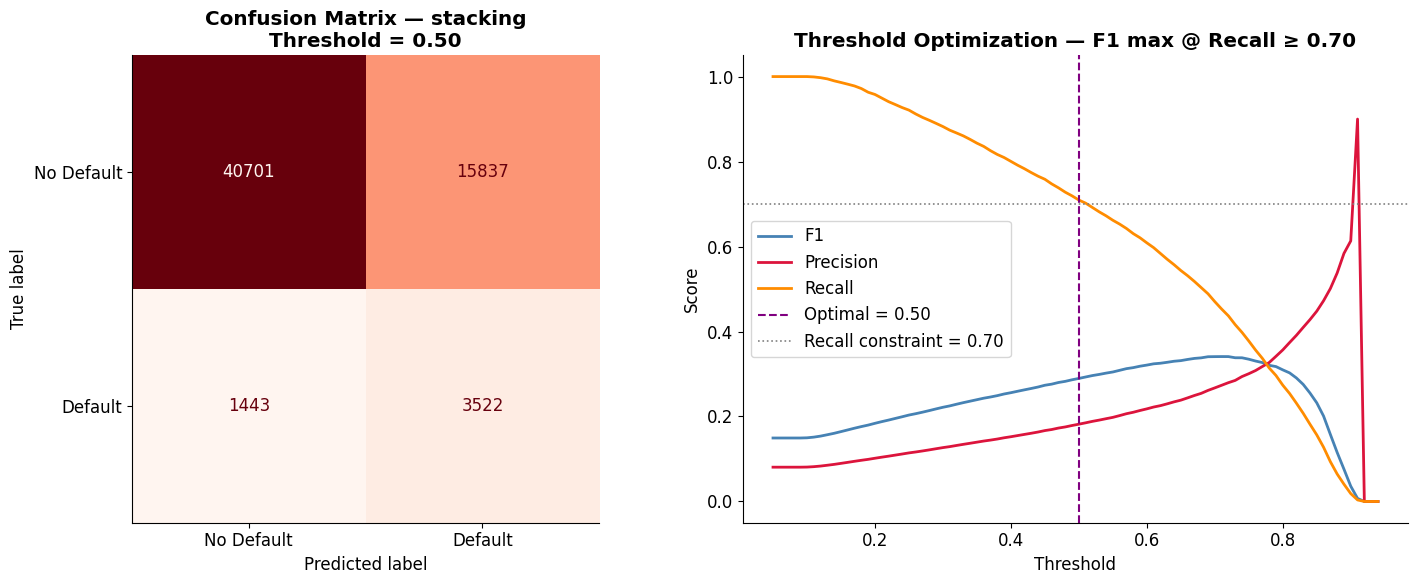

Validation set results @ threshold = 0.50:
  Default caught  (TP): 3,522   — 70.9% of all defaults detected
  Default missed  (FN): 1,443
  False alarm     (FP): 15,837   — 28.0% of good loans flagged
  Correct clear   (TN): 40,701

  Business impact:
  Defaults blocked : 3,522 / 4,965 (70.9%)
  Loans incorrectly rejected: 15,837


In [4]:
# ─— Confusion Matrix & Threshold Optimization ─────────────

if model_name == "stacking":
    xgb_p     = joblib.load(MODELS_DIR / "tuned_xgb.pkl").predict_proba(X_val)[:, 1]
    lgb_p     = joblib.load(MODELS_DIR / "tuned_lgb.pkl").predict_proba(X_val)[:, 1]
    cat_p     = joblib.load(MODELS_DIR / "tuned_cat.pkl").predict_proba(X_val)[:, 1]
    meta      = joblib.load(MODELS_DIR / "stacking_meta.pkl")
    best_prob = meta.predict_proba(np.column_stack([xgb_p, lgb_p, cat_p]))[:, 1]
else:
    parts     = model_name.split("_")
    best_prob = joblib.load(
        MODELS_DIR / f"{parts[0]}_{parts[1]}.pkl"
    ).predict_proba(X_val)[:, 1]

y_pred         = (best_prob >= threshold).astype(int)
cm             = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

disp = ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"])
disp.plot(ax=axes[0], colorbar=False, cmap="Reds")
axes[0].set_title(
    f"Confusion Matrix — {model_name}\nThreshold = {threshold:.2f}",
    fontweight="bold"
)

thresholds = np.arange(0.05, 0.95, 0.01)
f1s_   = [f1_score(y_val,        (best_prob >= t).astype(int), zero_division=0) for t in thresholds]
precs_ = [precision_score(y_val, (best_prob >= t).astype(int), zero_division=0) for t in thresholds]
recs_  = [recall_score(y_val,    (best_prob >= t).astype(int), zero_division=0) for t in thresholds]

axes[1].plot(thresholds, f1s_,   label="F1",        color="steelblue",  lw=2)
axes[1].plot(thresholds, precs_, label="Precision",  color="crimson",    lw=2)
axes[1].plot(thresholds, recs_,  label="Recall",     color="darkorange", lw=2)
axes[1].axvline(threshold, color="purple", ls="--", lw=1.5,
                label=f"Optimal = {threshold:.2f}")
axes[1].axhline(0.70, color="gray", ls=":", lw=1.2,
                label="Recall constraint = 0.70")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Threshold Optimization — F1 max @ Recall ≥ 0.70", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_BASE / "model" / "03_confusion_matrix_threshold.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Validation set results @ threshold = {threshold:.2f}:")
print(f"  Default caught  (TP): {tp:,}   — {tp/(tp+fn)*100:.1f}% of all defaults detected")
print(f"  Default missed  (FN): {fn:,}")
print(f"  False alarm     (FP): {fp:,}   — {fp/(fp+tn)*100:.1f}% of good loans flagged")
print(f"  Correct clear   (TN): {tn:,}")
print(f"\n  Business impact:")
print(f"  Defaults blocked : {tp:,} / {tp+fn:,} ({tp/(tp+fn)*100:.1f}%)")
print(f"  Loans incorrectly rejected: {fp:,}")

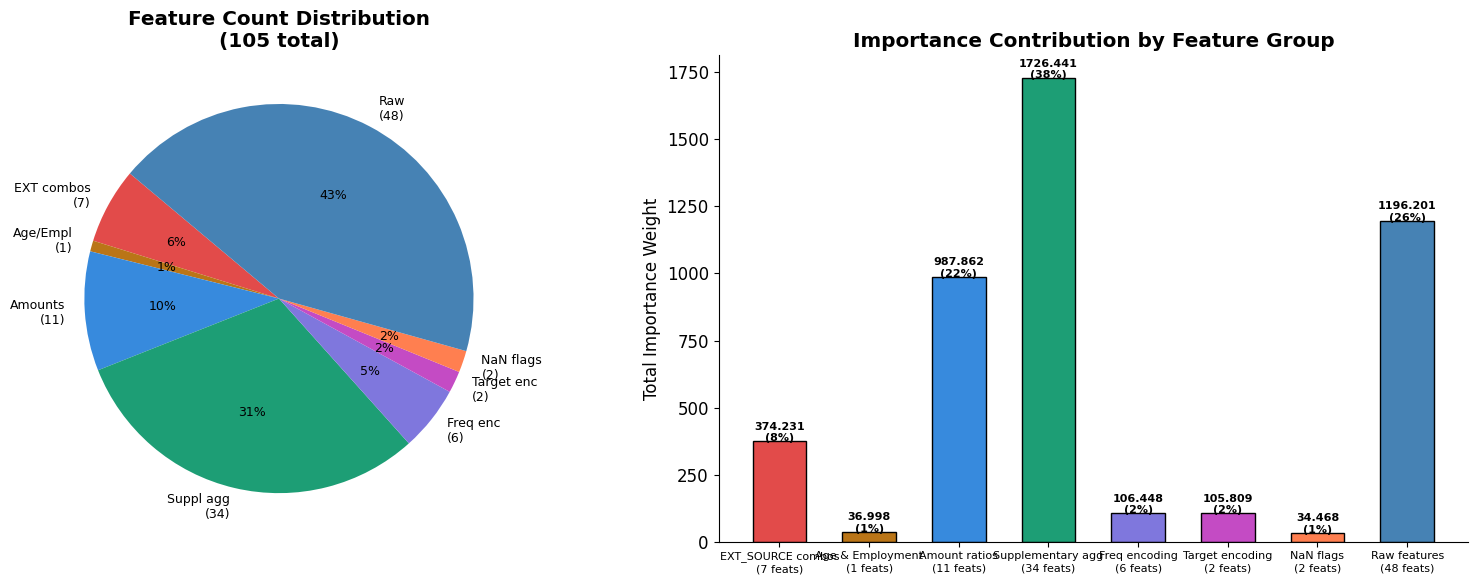

Importance share by feature group:
  Supplementary agg (34 feats)        1726.4410  (37.8%)
  Raw features (48 feats)             1196.2012  (26.2%)
  Amount ratios (11 feats)            987.8619  (21.6%)
  EXT_SOURCE combos (7 feats)         374.2310  (8.2%)
  Freq encoding (6 feats)             106.4476  (2.3%)
  Target encoding (2 feats)           105.8091  (2.3%)
  Age & Employment (1 feats)          36.9981  (0.8%)
  NaN flags (2 feats)                 34.4683  (0.8%)


In [5]:
# ─Feature Engineering Impact ───────────────────────────

fe_cols  = [c for c in X_val.columns if c.startswith("FE_")]
nan_cols = [c for c in X_val.columns if c.endswith("_isnan")]
raw_cols = [c for c in X_val.columns
            if not c.startswith("FE_") and not c.endswith("_isnan")]

# FE sub-groups
ext_cols  = [c for c in fe_cols if "ext" in c.lower()]
age_cols  = [c for c in fe_cols if any(k in c for k in ["age","employment","registration"])]
amt_cols  = [c for c in fe_cols if any(k in c for k in ["credit","annuity","income","goods"])]
supp_cols = [c for c in fe_cols if any(k in c for k in ["bureau","prev","pos","inst","cc"])]
freq_cols = [c for c in fe_cols if "freq" in c]
other_fe  = [c for c in fe_cols if c not in ext_cols+age_cols+amt_cols+supp_cols+freq_cols]

if model_name != "stacking":
    parts    = model_name.split("_")
    fi_model = joblib.load(MODELS_DIR / f"{parts[0]}_{parts[1]}.pkl")
    imp_all  = pd.Series(fi_model.feature_importances_, index=X_val.columns)
else:
    xgb = joblib.load(MODELS_DIR / "tuned_xgb.pkl")
    lgb = joblib.load(MODELS_DIR / "tuned_lgb.pkl")
    cat = joblib.load(MODELS_DIR / "tuned_cat.pkl")
    imp_all = (
        pd.Series(xgb.feature_importances_, index=X_val.columns) / 3 +
        pd.Series(lgb.feature_importances_, index=X_val.columns) / 3 +
        pd.Series(cat.feature_importances_, index=X_val.columns) / 3
    )

group_imp = {
    f"EXT_SOURCE combos\n({len(ext_cols)} feats)"  : imp_all[ext_cols].sum()  if ext_cols  else 0,
    f"Age & Employment\n({len(age_cols)} feats)"    : imp_all[age_cols].sum()  if age_cols  else 0,
    f"Amount ratios\n({len(amt_cols)} feats)"        : imp_all[amt_cols].sum()  if amt_cols  else 0,
    f"Supplementary agg\n({len(supp_cols)} feats)"  : imp_all[supp_cols].sum() if supp_cols else 0,
    f"Freq encoding\n({len(freq_cols)} feats)"      : imp_all[freq_cols].sum() if freq_cols else 0,
    f"Target encoding\n({len(other_fe)} feats)"     : imp_all[other_fe].sum()  if other_fe  else 0,
    f"NaN flags\n({len(nan_cols)} feats)"            : imp_all[nan_cols].sum()  if nan_cols  else 0,
    f"Raw features\n({len(raw_cols)} feats)"         : imp_all[raw_cols].sum()  if raw_cols  else 0,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sizes = [
    len(ext_cols), len(age_cols), len(amt_cols),
    len(supp_cols), len(freq_cols), len(other_fe),
    len(nan_cols), len(raw_cols),
]
labels_pie = [
    f"EXT combos\n({len(ext_cols)})",
    f"Age/Empl\n({len(age_cols)})",
    f"Amounts\n({len(amt_cols)})",
    f"Suppl agg\n({len(supp_cols)})",
    f"Freq enc\n({len(freq_cols)})",
    f"Target enc\n({len(other_fe)})",
    f"NaN flags\n({len(nan_cols)})",
    f"Raw\n({len(raw_cols)})",
]
colors_pie = ["#E24B4A","#BA7517","#378ADD","#1D9E75","#7F77DD","#C44BC4","coral","steelblue"]

axes[0].pie(sizes, labels=labels_pie, colors=colors_pie, autopct="%1.0f%%",
            startangle=140, textprops={"fontsize": 9})
axes[0].set_title(f"Feature Count Distribution\n({len(X_val.columns)} total)",
                  fontweight="bold")

bar_colors = ["#E24B4A","#BA7517","#378ADD","#1D9E75","#7F77DD","#C44BC4","coral","steelblue"]
bars = axes[1].bar(
    range(len(group_imp)), list(group_imp.values()),
    color=bar_colors, edgecolor="black", width=0.6
)
axes[1].set_xticks(range(len(group_imp)))
axes[1].set_xticklabels(list(group_imp.keys()), fontsize=8)
axes[1].set_ylabel("Total Importance Weight")
axes[1].set_title("Importance Contribution by Feature Group", fontweight="bold")
total_imp = sum(group_imp.values())
for bar, val in zip(bars, group_imp.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f"{val:.3f}\n({val/total_imp*100:.0f}%)",
                 ha="center", fontweight="bold", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_BASE / "model" / "05_feature_engineering_impact.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Importance share by feature group:")
for g, v in sorted(group_imp.items(), key=lambda x: x[1], reverse=True):
    print(f"  {g.replace(chr(10),' '):<35} {v:.4f}  ({v/total_imp*100:.1f}%)")

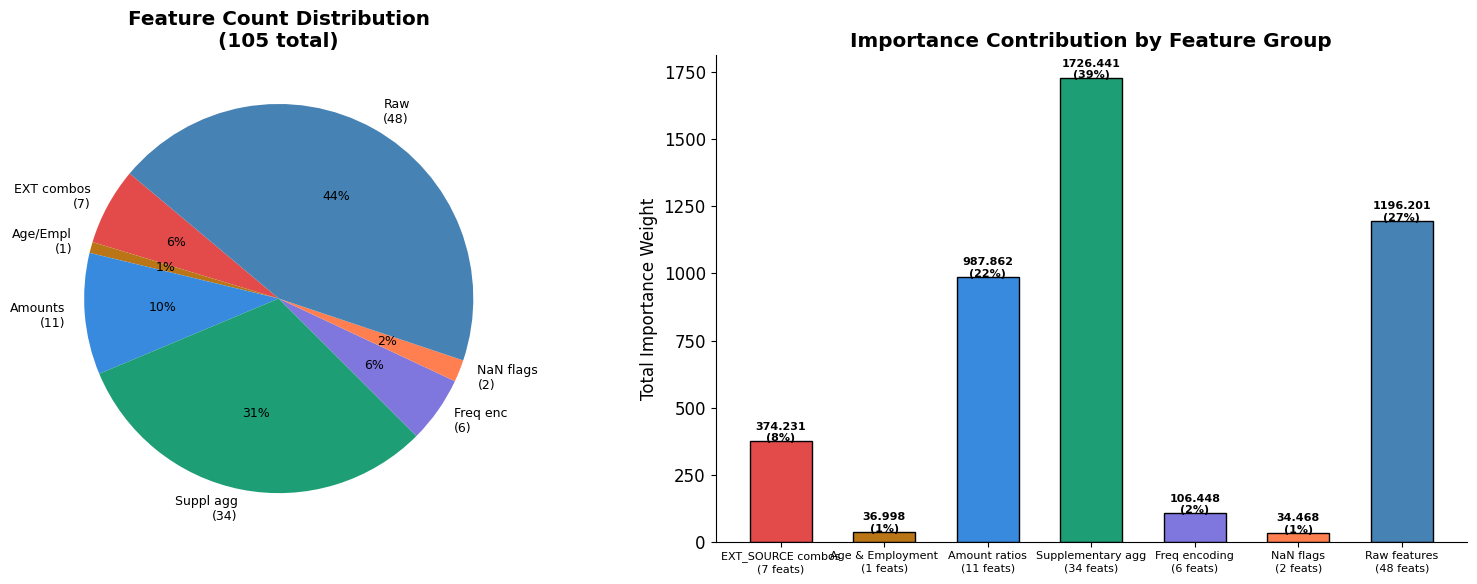

Importance share by feature group:
  Supplementary agg (34 feats)        1726.4410  (38.7%)
  Raw features (48 feats)             1196.2012  (26.8%)
  Amount ratios (11 feats)            987.8619  (22.1%)
  EXT_SOURCE combos (7 feats)         374.2310  (8.4%)
  Freq encoding (6 feats)             106.4476  (2.4%)
  Age & Employment (1 feats)          36.9981  (0.8%)
  NaN flags (2 feats)                 34.4683  (0.8%)


In [6]:
# ─Feature Engineering Impact ───────────────────────────

fe_cols  = [c for c in X_val.columns if c.startswith("FE_")]
nan_cols = [c for c in X_val.columns if c.endswith("_isnan")]
raw_cols = [c for c in X_val.columns
            if not c.startswith("FE_") and not c.endswith("_isnan")]

# FE sub-groups
ext_cols  = [c for c in fe_cols if "ext" in c.lower()]
age_cols  = [c for c in fe_cols if any(k in c for k in ["age","employment","registration"])]
amt_cols  = [c for c in fe_cols if any(k in c for k in ["credit","annuity","income","goods"])]
supp_cols = [c for c in fe_cols if any(k in c for k in ["bureau","prev","pos","inst","cc"])]
freq_cols = [c for c in fe_cols if "freq" in c]
other_fe  = [c for c in fe_cols if c not in ext_cols+age_cols+amt_cols+supp_cols+freq_cols]

if model_name != "stacking":
    parts    = model_name.split("_")
    fi_model = joblib.load(MODELS_DIR / f"{parts[0]}_{parts[1]}.pkl")
    imp_all  = pd.Series(fi_model.feature_importances_, index=X_val.columns)
else:
    xgb = joblib.load(MODELS_DIR / "tuned_xgb.pkl")
    lgb = joblib.load(MODELS_DIR / "tuned_lgb.pkl")
    cat = joblib.load(MODELS_DIR / "tuned_cat.pkl")
    imp_all = (
        pd.Series(xgb.feature_importances_, index=X_val.columns) / 3 +
        pd.Series(lgb.feature_importances_, index=X_val.columns) / 3 +
        pd.Series(cat.feature_importances_, index=X_val.columns) / 3
    )

group_imp = {
    f"EXT_SOURCE combos\n({len(ext_cols)} feats)" : imp_all[ext_cols].sum()  if ext_cols  else 0,
    f"Age & Employment\n({len(age_cols)} feats)"   : imp_all[age_cols].sum()  if age_cols  else 0,
    f"Amount ratios\n({len(amt_cols)} feats)"       : imp_all[amt_cols].sum()  if amt_cols  else 0,
    f"Supplementary agg\n({len(supp_cols)} feats)"  : imp_all[supp_cols].sum() if supp_cols else 0,
    f"Freq encoding\n({len(freq_cols)} feats)"      : imp_all[freq_cols].sum() if freq_cols else 0,
    f"NaN flags\n({len(nan_cols)} feats)"            : imp_all[nan_cols].sum()  if nan_cols  else 0,
    f"Raw features\n({len(raw_cols)} feats)"         : imp_all[raw_cols].sum()  if raw_cols  else 0,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sizes  = [len(ext_cols), len(age_cols), len(amt_cols),
          len(supp_cols), len(freq_cols), len(nan_cols), len(raw_cols)]
labels_pie = [f"EXT combos\n({len(ext_cols)})",
              f"Age/Empl\n({len(age_cols)})",
              f"Amounts\n({len(amt_cols)})",
              f"Suppl agg\n({len(supp_cols)})",
              f"Freq enc\n({len(freq_cols)})",
              f"NaN flags\n({len(nan_cols)})",
              f"Raw\n({len(raw_cols)})"]
colors_pie = ["#E24B4A","#BA7517","#378ADD","#1D9E75","#7F77DD","coral","steelblue"]
axes[0].pie(sizes, labels=labels_pie, colors=colors_pie, autopct="%1.0f%%",
            startangle=140, textprops={"fontsize": 9})
axes[0].set_title(f"Feature Count Distribution\n({len(X_val.columns)} total)",
                  fontweight="bold")

bar_colors = ["#E24B4A","#BA7517","#378ADD","#1D9E75","#7F77DD","coral","steelblue"]
bars = axes[1].bar(
    range(len(group_imp)), list(group_imp.values()),
    color=bar_colors, edgecolor="black", width=0.6
)
axes[1].set_xticks(range(len(group_imp)))
axes[1].set_xticklabels(list(group_imp.keys()), fontsize=8)
axes[1].set_ylabel("Total Importance Weight")
axes[1].set_title("Importance Contribution by Feature Group", fontweight="bold")
total_imp = sum(group_imp.values())
for bar, val in zip(bars, group_imp.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f"{val:.3f}\n({val/total_imp*100:.0f}%)",
                 ha="center", fontweight="bold", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_BASE / "model" / "05_feature_engineering_impact.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Importance share by feature group:")
for g, v in sorted(group_imp.items(), key=lambda x: x[1], reverse=True):
    print(f"  {g.replace(chr(10),' '):<35} {v:.4f}  ({v/total_imp*100:.1f}%)")

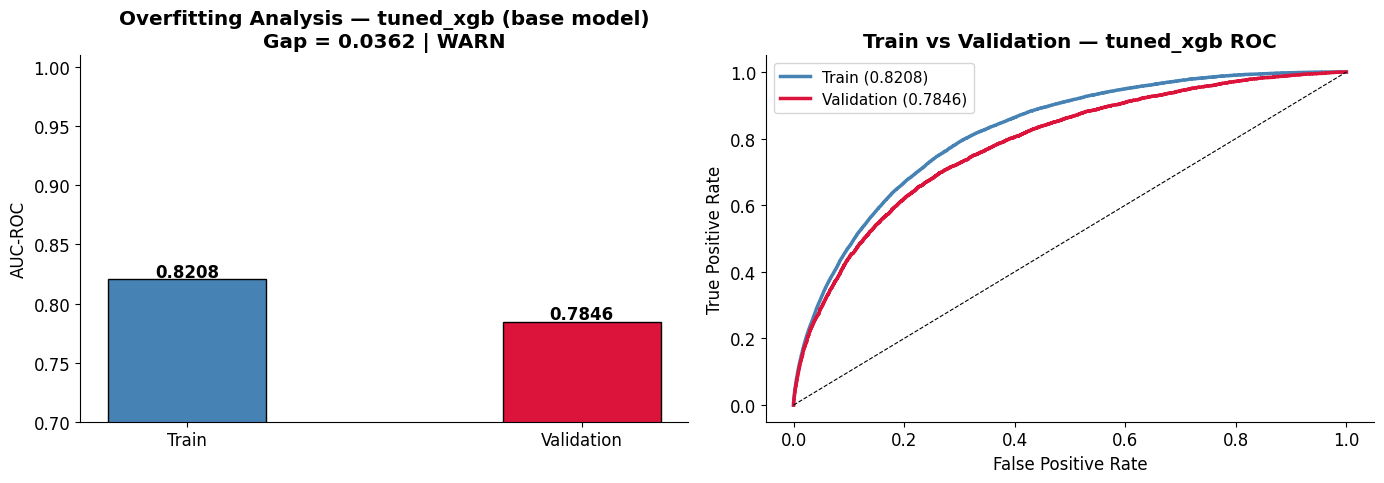

Overfitting check (tuned_xgb as base model proxy):
Train AUC      : 0.8208
Validation AUC : 0.7846
Gap            : 0.0362 → WARN

Note: Best model is stacking (AUC=0.7849)
      Stacking trained on OOF — no direct train/val gap measurable


In [7]:
# ─— Overfitting Analysis ──────────────────────────────────

train   = pd.read_parquet(FEATURES_DIR / "train_credit_features.parquet")
X_train = train.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y_train = train["TARGET"]

if model_name != "stacking":
    parts      = model_name.split("_")
    chk_model  = joblib.load(MODELS_DIR / f"{parts[0]}_{parts[1]}.pkl")
    train_prob = chk_model.predict_proba(X_train)[:, 1]
    train_auc  = roc_auc_score(y_train, train_prob)
    val_auc    = metadata["auc_roc"]
    gap        = train_auc - val_auc
    status     = "PASS" if gap < 0.02 else "WARN" if gap < 0.05 else "OVERFIT"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    bars = axes[0].bar(
        ["Train", "Validation"], [train_auc, val_auc],
        color=["steelblue", "crimson"], edgecolor="black", width=0.4
    )
    axes[0].set_ylim(0.70, 1.01)
    axes[0].set_ylabel("AUC-ROC")
    axes[0].set_title(
        f"Overfitting Analysis — {model_name}\nGap = {gap:.4f} | {status}",
        fontweight="bold"
    )
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center", fontweight="bold", fontsize=12
        )

    fpr_tr, tpr_tr, _ = roc_curve(y_train, train_prob)
    fpr_v,  tpr_v,  _ = roc_curve(y_val,   best_prob)
    axes[1].plot(fpr_tr, tpr_tr, color="steelblue", lw=2.5, label=f"Train ({train_auc:.4f})")
    axes[1].plot(fpr_v,  tpr_v,  color="crimson",   lw=2.5, label=f"Validation ({val_auc:.4f})")
    axes[1].plot([0,1],[0,1], "k--", lw=0.8)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("Train vs Validation — ROC Curve", fontweight="bold")
    axes[1].legend(fontsize=11)

    plt.tight_layout()
    plt.savefig(FIG_BASE / "model" / "06_overfitting_analysis.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Train AUC      : {train_auc:.4f}")
    print(f"Validation AUC : {val_auc:.4f}")
    print(f"Gap            : {gap:.4f} → {status}")

else:
    chk_model    = joblib.load(MODELS_DIR / "tuned_xgb.pkl")
    train_prob   = chk_model.predict_proba(X_train)[:, 1]
    xgb_val_prob = chk_model.predict_proba(X_val)[:, 1]
    train_auc    = roc_auc_score(y_train, train_prob)
    val_auc_xgb  = roc_auc_score(y_val,   xgb_val_prob)
    gap          = train_auc - val_auc_xgb
    status       = "PASS" if gap < 0.02 else "WARN" if gap < 0.05 else "OVERFIT"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    bars = axes[0].bar(
        ["Train", "Validation"],
        [train_auc, val_auc_xgb],
        color=["steelblue", "crimson"], edgecolor="black", width=0.4
    )
    axes[0].set_ylim(0.70, 1.01)
    axes[0].set_ylabel("AUC-ROC")
    axes[0].set_title(
        f"Overfitting Analysis — tuned_xgb (base model)\nGap = {gap:.4f} | {status}",
        fontweight="bold"
    )
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center", fontweight="bold", fontsize=12
        )

    fpr_tr, tpr_tr, _ = roc_curve(y_train, train_prob)
    fpr_v,  tpr_v,  _ = roc_curve(y_val,   xgb_val_prob)
    axes[1].plot(fpr_tr, tpr_tr, color="steelblue", lw=2.5, label=f"Train ({train_auc:.4f})")
    axes[1].plot(fpr_v,  tpr_v,  color="crimson",   lw=2.5, label=f"Validation ({val_auc_xgb:.4f})")
    axes[1].plot([0,1],[0,1], "k--", lw=0.8)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("Train vs Validation — tuned_xgb ROC", fontweight="bold")
    axes[1].legend(fontsize=11)

    plt.tight_layout()
    plt.savefig(FIG_BASE / "model" / "06_overfitting_analysis.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Overfitting check (tuned_xgb as base model proxy):")
    print(f"Train AUC      : {train_auc:.4f}")
    print(f"Validation AUC : {val_auc_xgb:.4f}")
    print(f"Gap            : {gap:.4f} → {status}")
    print(f"\nNote: Best model is stacking (AUC={metadata['auc_roc']:.4f})")
    print(f"      Stacking trained on OOF — no direct train/val gap measurable")

In [8]:
# ─— Final Summary ────────────────────────────────────────

fe_cols  = [c for c in X_val.columns if c.startswith("FE_")]
nan_cols = [c for c in X_val.columns if c.endswith("_isnan")]
raw_cols = [c for c in X_val.columns
            if not c.startswith("FE_") and not c.endswith("_isnan")]

print("=" * 60)
print("FINRISKGUARD — CREDIT SCORING FINAL SUMMARY")
print("=" * 60)
print(f"\nBest model       : {model_name}")
print(f"AUC-ROC          : {metadata['auc_roc']:.4f}  (primary metric)")
print(f"AUC-PR           : {metadata['auc_pr']:.4f}  (imbalance-aware)")
print(f"F1-score         : {metadata['f1']:.4f}")
print(f"Precision        : {metadata['precision']:.4f}")
print(f"Recall           : {metadata['recall']:.4f}")
print(f"Threshold        : {metadata['threshold']:.3f}")
print(f"Imbalance ratio  : 11.4:1 (8.07% default rate)")
print(f"Features used    : {len(X_val.columns)}")
print(f"  FE_ engineered : {len(fe_cols)}")
print(f"  NaN flags      : {len(nan_cols)}")
print(f"  Raw features   : {len(raw_cols)}")
print(f"\nSaved figures:")
for f in sorted(FIG_BASE.rglob("*.png")):
    rel = f.relative_to(FIG_BASE.parent.parent)
    print(f"  {rel}")

FINRISKGUARD — CREDIT SCORING FINAL SUMMARY

Best model       : stacking
AUC-ROC          : 0.7849  (primary metric)
AUC-PR           : 0.2854  (imbalance-aware)
F1-score         : 0.2896
Precision        : 0.1819
Recall           : 0.7098
Threshold        : 0.500
Imbalance ratio  : 11.4:1 (8.07% default rate)
Features used    : 105
  FE_ engineered : 55
  NaN flags      : 2
  Raw features   : 48

Saved figures:
  figures\credit\comparison\01_model_leaderboard.png
  figures\credit\comparison\leaderboard.png
  figures\credit\eda\01_target\target_overview.png
  figures\credit\eda\02_missing\missing_overview.png
  figures\credit\eda\02_missing\nan_flag_justification.png
  figures\credit\eda\03_amounts\amount_distributions.png
  figures\credit\eda\03_amounts\income_skewness.png
  figures\credit\eda\03_amounts\ratio_features.png
  figures\credit\eda\04_categorical\categorical_default_rates.png
  figures\credit\eda\04_categorical\occupation_type_default.png
  figures\credit\eda\04_categorica